## Exercício Prático — Aula 02

Use o `df_outlier` e `df_sem_outlier` criados nesta aula:

1. **Outliers em Quantidade**: usando o método IQR, detecte e liste os outliers da coluna `'Quantidade'`. Quantos são?

2. **Z-Score manual**: normalize a coluna `'Preço Unitário'` usando Z-Score. Verifique que a média resultante é ≈ 0 e o desvio padrão ≈ 1.

3. **apply() com lógica**: crie a coluna `'Horário_Venda'` a partir da coluna `'Data'`, classificando:
   - Hora < 12 → `'Manhã'`
   - Hora < 18 → `'Tarde'`
   - Caso contrário → `'Noite'`
   Dica: use `df['Data'].dt.hour`.

4. **pd.cut() com quantis**: use `pd.qcut()` (em vez de `pd.cut()`) para dividir `'Valor Líquido'` em 4 quartis iguais. Qual a diferença entre `cut` e `qcut`?

5. **Gráfico**: plote um gráfico de barras mostrando a **soma do Valor Líquido por Categoria**, com as barras ordenadas do maior para o menor.

## Gabarito — Pontos Principais

### Exercício 1 — Outliers em Quantidade
```python
Q1 = df_outlier['Quantidade'].quantile(0.25)
Q3 = df_outlier['Quantidade'].quantile(0.75)
IQR = Q3 - Q1
limite_sup = Q3 + 1.5 * IQR
outliers_qtd = df_outlier[df_outlier['Quantidade'] > limite_sup]
print(f"Outliers em Quantidade: {len(outliers_qtd)}")
```

### Exercício 3 — apply() com horário
```python
# Como 'Data' é datetime sem hora, hora sempre será 0
# Para simular: df['Data'].dt.hour
# Mas se todas forem 0, o resultado será 'Manhã' para todas
```

### Exercício 4 — Diferença cut vs qcut
```python
# pd.cut()  → bins com largura IGUAL (divide o intervalo igualmente)
# pd.qcut() → bins com FREQUÊNCIA IGUAL (cada bin tem mesma qtd de registros)
df_sem_outlier['Quartil'] = pd.qcut(df_sem_outlier['Valor Líquido'], q=4,
                                    labels=['Q1','Q2','Q3','Q4'])
print(df_sem_outlier['Quartil'].value_counts().sort_index())
```

### Exercício 5 — Soma por Categoria
```python
vendas_cat = df_sem_outlier.groupby('Categoria')['Valor Líquido'].sum().sort_values(ascending=False)
plt.barh(vendas_cat.index, vendas_cat.values, color='steelblue')
plt.title('Total de Vendas por Categoria')
plt.xlabel('Valor Total (R$)')
plt.tight_layout()
plt.show()
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("../bases/base_vendas_supermercado.xlsx")
df_limpo = df.copy()

np.random.seed(99)
df_outlier = df_limpo.copy()

idx_preco_alto  = np.random.choice(df_outlier.index, 4, replace=False)
idx_preco_baixo = np.random.choice(df_outlier.index, 3, replace=False)
idx_qtd_alta    = np.random.choice(df_outlier.index, 3, replace=False)

df_outlier.loc[idx_preco_alto,  'Valor Líquido'] = [850.0, 1200.0, 980.0, 760.0]
df_outlier.loc[idx_preco_baixo, 'Valor Líquido'] = [0.50, 0.30, 0.10]
df_outlier.loc[idx_qtd_alta,    'Quantidade']    = [50, 80, 120]

Q1_venda = df_outlier['Valor Líquido'].quantile(0.25)
Q3_venda = df_outlier['Valor Líquido'].quantile(0.75)
IQR_venda = Q3_venda - Q1_venda
mask_outlier_venda = (df_outlier['Valor Líquido'] < (Q1_venda - 1.5 * IQR_venda)) | (df_outlier['Valor Líquido'] > (Q3_venda + 1.5 * IQR_venda))
df_sem_outlier = df_outlier[~mask_outlier_venda].copy()

print("Setup concluído com sucesso!")

d:\SENAI\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
d:\SENAI\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


Setup concluído com sucesso!


In [2]:
Q1_qtd = df_outlier['Quantidade'].quantile(0.25)
Q3_qtd = df_outlier['Quantidade'].quantile(0.75)
IQR_qtd = Q3_qtd - Q1_qtd

limite_inf_qtd = Q1_qtd - 1.5 * IQR_qtd
limite_sup_qtd = Q3_qtd + 1.5 * IQR_qtd

mask_outlier_qtd = (df_outlier['Quantidade'] < limite_inf_qtd) | (df_outlier['Quantidade'] > limite_sup_qtd)
outliers_quantidade = df_outlier[mask_outlier_qtd]

print(f"Limites para Quantidade: {limite_inf_qtd} até {limite_sup_qtd}")
print(f"Quantidade de outliers detectados: {len(outliers_quantidade)}")
print("\nLinhas identificadas como outliers de Quantidade:")
print(outliers_quantidade[['Data', 'Produto', 'Quantidade', 'Valor Líquido']].to_string())

Limites para Quantidade: -4.0 até 12.0
Quantidade de outliers detectados: 3

Linhas identificadas como outliers de Quantidade:
          Data             Produto  Quantidade  Valor Líquido
63  2026-04-23      Mortadela 300g          50          57.06
125 2026-01-12  Feijão Carioca 1kg         120          59.50
243 2026-01-17   Leite Integral 1L          80          37.69


In [3]:
df_ex2 = df_sem_outlier.copy()

media_preco = df_ex2['Preço Unitário'].mean()
desvio_preco = df_ex2['Preço Unitário'].std()
df_ex2['Preço_Unitário_z'] = (df_ex2['Preço Unitário'] - media_preco) / desvio_preco

print(f"Média resultante (deve ser próx. de 0): {df_ex2['Preço_Unitário_z'].mean().round(4)}")
print(f"Desvio padrão resultante (deve ser 1): {df_ex2['Preço_Unitário_z'].std().round(4)}")

Média resultante (deve ser próx. de 0): 0.0
Desvio padrão resultante (deve ser 1): 1.0


In [4]:
df_ex3 = df_sem_outlier.copy()

np.random.seed(42)
df_ex3['Data'] = df_ex3['Data'] + pd.to_timedelta(np.random.randint(8, 22, size=len(df_ex3)), unit='h')

def classificar_horario(data_hora):
    hora = data_hora.hour
    if hora < 12:
        return 'Manhã'
    elif hora < 18:
        return 'Tarde'
    else:
        return 'Noite'

df_ex3['Horário_Venda'] = df_ex3['Data'].apply(classificar_horario)
print("Distribuição das vendas por turno (Simulado):")
print(df_ex3['Horário_Venda'].value_counts().to_string())

Distribuição das vendas por turno (Simulado):
Horário_Venda
Tarde    101
Noite     78
Manhã     57


In [5]:
df_ex4 = df_sem_outlier.copy()

df_ex4['Quartil_Valor'] = pd.qcut(df_ex4['Valor Líquido'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

print("Quantidade de registros por Quartil (usando qcut):")
print(df_ex4['Quartil_Valor'].value_counts().sort_index().to_string())
print("\nExplicação teórica:")
print("- pd.cut():  Divide o espaço dos valores em intervalos de larguras iguais (ex: 0-50, 50-100).")
print("- pd.qcut(): Divide os dados garantindo que cada faixa tenha a mesma QUANTIDADE de linhas.")

Quantidade de registros por Quartil (usando qcut):
Quartil_Valor
Q1    59
Q2    59
Q3    59
Q4    59

Explicação teórica:
- pd.cut():  Divide o espaço dos valores em intervalos de larguras iguais (ex: 0-50, 50-100).
- pd.qcut(): Divide os dados garantindo que cada faixa tenha a mesma QUANTIDADE de linhas.


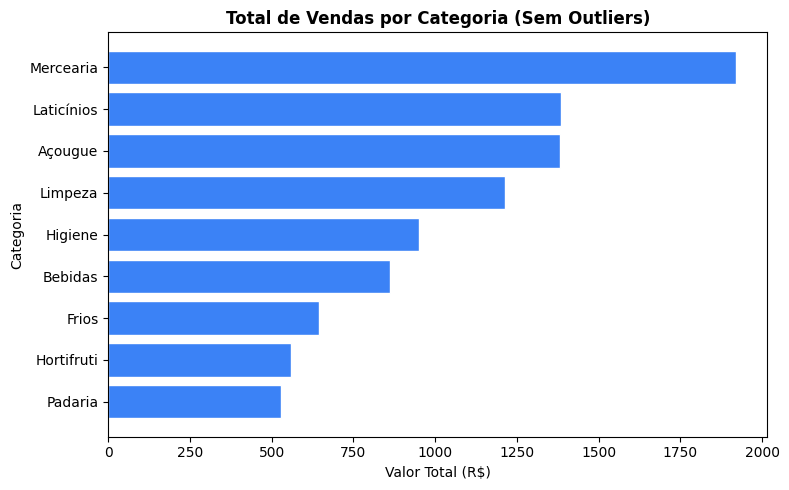

In [6]:
vendas_por_categoria = df_sem_outlier.groupby('Categoria')['Valor Líquido'].sum().sort_values(ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(vendas_por_categoria.index, vendas_por_categoria.values, color='#3b82f6', edgecolor='white')

plt.title('Total de Vendas por Categoria (Sem Outliers)', fontweight='bold')
plt.xlabel('Valor Total (R$)')
plt.ylabel('Categoria')
plt.tight_layout()
plt.show()